### Importing the libraries  

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Retrieve the dataset

In [189]:
df = pd.read_csv("./data/ad_click_prediction_train.csv")
df_test = pd.read_csv("./data/ad_click_prediction_test.csv")
df.head()

,session_id,DateTime,user_id,product,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,gender,age_level,user_depth,city_development_index,var_1,is_click
0,140690,2017-07-02 00:00,858557,C,359520,13787,4,NaN,10.0,Female,4.0,3.0,3.0,0,0
1,333291,2017-07-02 00:00,243253,C,105960,11085,5,NaN,8.0,Female,2.0,2.0,NaN,0,0
2,129781,2017-07-02 00:00,243253,C,359520,13787,4,NaN,8.0,Female,2.0,2.0,NaN,0,0
3,464848,2017-07-02 00:00,1097446,I,359520,13787,3,NaN,3.0,Male,3.0,3.0,2.0,1,0
4,90569,2017-07-02 00:01,663656,C,405490,60305,3,NaN,2.0,Male,2.0,3.0,2.0,1,0


1. Data Preparation & Feature Engineering: Quality of data cleaning, imputation, handling of categorical data, and the predictive power of engineered features (behavioral, temporal, contextual).

In [190]:
df.shape

(463291, 15)

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   session_id              463291 non-null  int64  
 1   DateTime                463291 non-null  object 
 2   user_id                 463291 non-null  int64  
 3   product                 463291 non-null  object 
 4   campaign_id             463291 non-null  int64  
 5   webpage_id              463291 non-null  int64  
 6   product_category_1      463291 non-null  int64  
 7   product_category_2      97437 non-null   float64
 8   user_group_id           445048 non-null  float64
 9   gender                  445048 non-null  object 
 10  age_level               445048 non-null  float64
 11  user_depth              445048 non-null  float64
 12  city_development_index  338162 non-null  float64
 13  var_1                   463291 non-null  int64  
 14  is_click            

In [192]:
df.nunique()

session_id                463291
DateTime                    8610
user_id                   150347
product                       10
campaign_id                   10
webpage_id                     9
product_category_1             5
product_category_2            29
user_group_id                 13
gender                         2
age_level                      7
user_depth                     3
city_development_index         4
var_1                          2
is_click                       2
dtype: int64

In [193]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
identifier = ['session_id', 'user_id']
categorical = ['product', 'campaign_id', 'webpage_id', 'product_category_1', 'product_category_2', 'user_group_id', 'gender', 'user_depth', 'city_development_index', 'var_1', 'is_click']
categorical_ordinal = ['age_level']
temporal = ['DateTime']
numerical = []

In [194]:
ctr = df['is_click'].mean()
print(f"CTR: {ctr:.4%}")

CTR: 6.7627%


In [195]:
df.isnull().sum()

session_id                     0
DateTime                       0
user_id                        0
product                        0
campaign_id                    0
webpage_id                     0
product_category_1             0
product_category_2        365854
user_group_id              18243
gender                     18243
age_level                  18243
user_depth                 18243
city_development_index    125129
var_1                          0
is_click                       0
dtype: int64

## 1. Target Distribution & Imbalance Analysis
- What percentage of ads get clicked?
- Is the dataset severely imbalanced?
- Do you need resampling techniques?

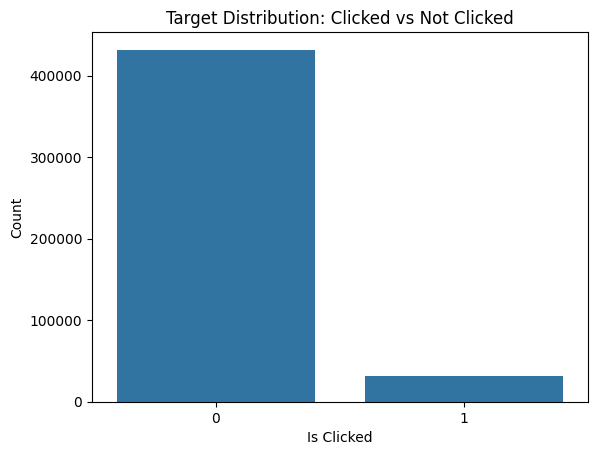

Clicked: 31331 (6.76%)
Not Clicked: 431960 (93.24%)
The dataset is imbalanced. Consider resampling techniques.


In [196]:
# Plot target distribution
import matplotlib.pyplot as plt
sns.countplot(x='is_click', data=df)
plt.title('Target Distribution: Clicked vs Not Clicked')
plt.xlabel('Is Clicked')
plt.ylabel('Count')
plt.show()

# Calculate class balance
clicked = df['is_click'].sum()
total = len(df)
not_clicked = total - clicked
print(f"Clicked: {clicked} ({clicked/total:.2%})\nNot Clicked: {not_clicked} ({not_clicked/total:.2%})")

# Imbalance check
imbalance_ratio = clicked / total
if imbalance_ratio < 0.2 or imbalance_ratio > 0.8:
    print('The dataset is imbalanced. Consider resampling techniques.')
else:
    print('The dataset is reasonably balanced.')

## 2. Temporal Patterns in Click Rates
- Which hours have highest click rates?
- Are weekends different from weekdays?
- Do certain months perform better?

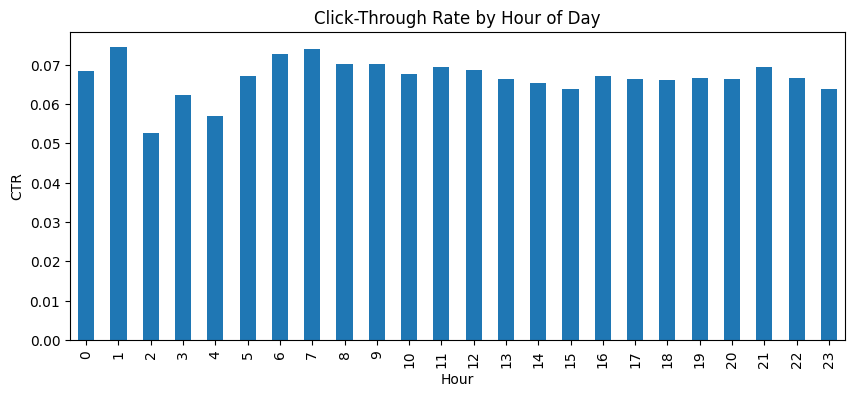

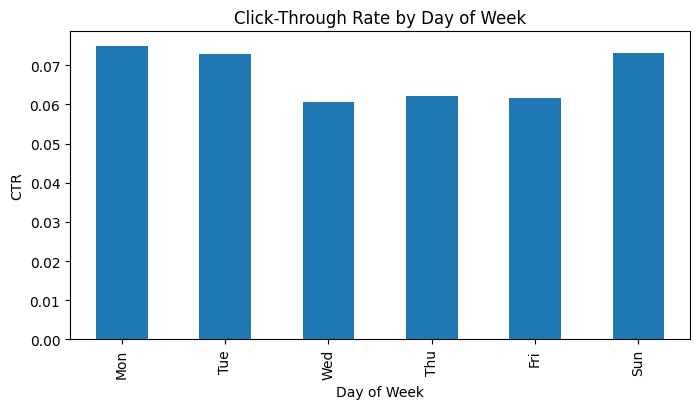

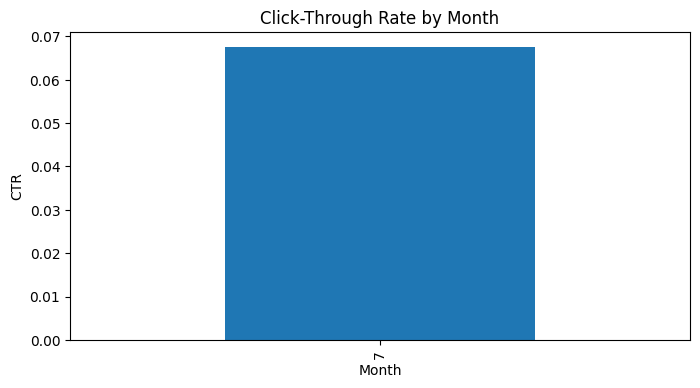

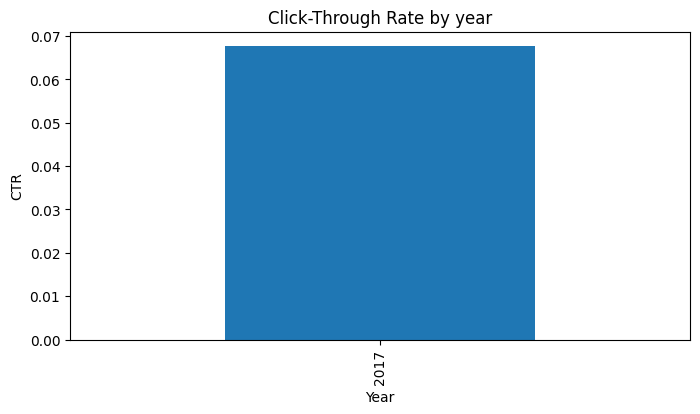

In [197]:
# Extract temporal features
# Hour of day
if 'hour' not in df.columns:
    df['hour'] = df['DateTime'].dt.hour
# Day of week
if 'weekday' not in df.columns:
    df['weekday'] = df['DateTime'].dt.dayofweek
# Month
if 'month' not in df.columns:
    df['month'] = df['DateTime'].dt.month

if 'year' not in df.columns:
    df['year'] = df['DateTime'].dt.year

# Click rate by hour
hourly_ctr = df.groupby('hour')['is_click'].mean()
hourly_ctr.plot(kind='bar', figsize=(10,4))
plt.title('Click-Through Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('CTR')
plt.show()

# Click rate by weekday
weekday_ctr = df.groupby('weekday')['is_click'].mean()
weekday_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
weekday_ctr.index = [weekday_names[i] for i in weekday_ctr.index]
weekday_ctr.plot(kind='bar', figsize=(8,4))
plt.title('Click-Through Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('CTR')
plt.show()

# Click rate by month
monthly_ctr = df.groupby('month')['is_click'].mean()
monthly_ctr.plot(kind='bar', figsize=(8,4))
plt.title('Click-Through Rate by Month')
plt.xlabel('Month')
plt.ylabel('CTR')
plt.show()

# Click rate by year
monthly_ctr = df.groupby('year')['is_click'].mean()
monthly_ctr.plot(kind='bar', figsize=(8,4))
plt.title('Click-Through Rate by year')
plt.xlabel('Year')
plt.ylabel('CTR')
plt.show()

> Data is present for the month of july 2017

In [198]:
print("Unique weekdays in dataset:")
print(df['weekday'].unique())
print("\nWeekday value counts:")
print(df['weekday'].value_counts().sort_index())

Unique weekdays in dataset:
[6 0 1 2 3 4]

Weekday value counts:
weekday
0    81380
1    73085
2    80789
3    77526
4    71466
6    79045
Name: count, dtype: int64


In [199]:
df_test['DateTime'] = pd.to_datetime(df_test['DateTime'])
if 'hour' not in df_test.columns:
    df_test['hour'] = df_test['DateTime'].dt.hour
# Day of week
if 'weekday' not in df_test.columns:
    df_test['weekday'] = df_test['DateTime'].dt.dayofweek
# Month
if 'month' not in df_test.columns:
    df_test['month'] = df_test['DateTime'].dt.month

print("Unique weekdays in dataset:")
print(df_test['weekday'].unique())
print("\nWeekday value counts:")
print(df_test['weekday'].value_counts().sort_index())

Unique weekdays in dataset:
[5 6]

Weekday value counts:
weekday
5    66874
6    61984
Name: count, dtype: int64


In [200]:
# Check if test set has target variable
print("Test dataset columns:")
print(df_test.columns.tolist())
print(f"\nTest dataset shape: {df_test.shape}")
print(f"Has 'is_click' column: {'is_click' in df_test.columns}")

Test dataset columns:
['session_id', 'DateTime', 'user_id', 'product', 'campaign_id', 'webpage_id', 'product_category_1', 'product_category_2', 'user_group_id', 'gender', 'age_level', 'user_depth', 'city_development_index', 'var_1', 'hour', 'weekday', 'month']

Test dataset shape: (128858, 17)
Has 'is_click' column: False


> **Finding:** Cannot Merge Test dataset does NOT have the `is_click` target variable.

In [201]:
print("Top 5 hours with highest CTR")
print(hourly_ctr.sort_values(ascending=False).head(5))

print("Bottom 5 hours with lowest CTR")
print(hourly_ctr.sort_values().head(5))

Top 5 hours with highest CTR
hour
1    0.074608
7    0.073978
6    0.072822
8    0.070271
9    0.070101
Name: is_click, dtype: float64
Bottom 5 hours with lowest CTR
hour
2     0.052732
4     0.057005
3     0.062237
23    0.063736
15    0.063929
Name: is_click, dtype: float64


> Which hours have highest click rates?

> Data shows that Best hours for highest CTR are 1, 7, 6, 8, 9

> Are weekends different from weekdays?

In [202]:
weekdays_ctr = weekday_ctr.drop(columns=['Sun']).mean()

print(f"Weekdays CTR {weekdays_ctr}")
print(f"Weekend CTR {weekday_ctr['Sun']}")
weekdays_diff_in_per = ((weekday_ctr['Sun'] - weekdays_ctr) / weekdays_ctr)
print(f"{weekdays_diff_in_per:.4%}")

Weekdays CTR 0.06756825031976356
Weekend CTR 0.07326206591182238
8.4268%


> User Behavior

> Do certain age groups click more?

In [203]:
age_level_ctr = df.groupby('age_level')['is_click'].mean()
age_level_ctr.sort_values(ascending=False)

age_level
0.0    0.084967
6.0    0.082276
1.0    0.074803
5.0    0.074153
2.0    0.070919
3.0    0.064516
4.0    0.058723
Name: is_click, dtype: float64

> Is there a gender difference in click rates?

In [204]:
gender_ctr = df.groupby('gender')['is_click'].mean()
gender_diff_in_per = ((gender_ctr['Male'] - gender_ctr['Female']) / gender_ctr['Female'])
print(f"{gender_diff_in_per:.4%}")

5.4253%


In [205]:
df.columns

Index(['session_id', 'DateTime', 'user_id', 'product', 'campaign_id',
       'webpage_id', 'product_category_1', 'product_category_2',
       'user_group_id', 'gender', 'age_level', 'user_depth',
       'city_development_index', 'var_1', 'is_click', 'hour', 'weekday',
       'month', 'year'],
      dtype='object')

> How does user group affect clicking? 

In [206]:
user_depth_ctr = df.groupby('user_depth')['is_click'].mean()
user_depth_ctr

user_depth
1.0    0.071916
2.0    0.065517
3.0    0.067560
Name: is_click, dtype: float64

> Which campaigns have highest CTR?

In [207]:
campaign_ctr = df.groupby('campaign_id')['is_click'].mean()
campaign_ctr.sort_values(ascending=False).head(10)

campaign_id
405490    0.091307
404347    0.077534
98970     0.076829
396664    0.072624
105960    0.068345
82320     0.063772
359520    0.058620
414149    0.058334
118601    0.053362
360936    0.045213
Name: is_click, dtype: float64

> Which products get more clicks? 

In [208]:
product_ctr = df.groupby('product_category_1')['is_click'].mean()
product_ctr.sort_values(ascending=False).head(10)

product_category_1
3    0.083524
1    0.071554
2    0.061720
5    0.059121
4    0.058932
Name: is_click, dtype: float64

> Do certain webpages convert better?

In [209]:
webpage_ctr = df.groupby('webpage_id')['is_click'].mean()
webpage_ctr.sort_values(ascending=False).head(10)

webpage_id
60305    0.091307
53587    0.077534
6970     0.076829
51181    0.072624
11085    0.068345
1734     0.063772
45962    0.058334
13787    0.054273
28529    0.053362
Name: is_click, dtype: float64

#### Feature Engineering

## Feature Engineering Strategy

Comprehensive feature engineering to capture:
1. **DateTime Features**: Temporal patterns in user behavior
2. **Interaction Features**: Hidden patterns from feature combinations
3. **Aggregated Features**: Historical performance metrics

## Phase 3: Data Preprocessing

Prepare the data for machine learning by handling missing values, encoding categorical variables, and selecting relevant features.

### Step 1: Handle Missing Values

**Strategy:**
- **Numerical columns:** Fill with median (robust to outliers)
- **Categorical columns:** Fill with mode (most frequent value)

In [210]:
def handle_missing_values(df_train, df_test, verbose=True):
    """
    Handle missing values in training and test datasets
    - Numerical columns: Fill with median from training data
    - Categorical columns: Fill with mode from training data
    """
    df_train = df_train.copy()
    df_test = df_test.copy()
    
    if verbose:
        print("=" * 70)
        print("STEP 1: HANDLING MISSING VALUES")
        print("=" * 70)
    
    # Check missing values before
    train_missing = df_train.isnull().sum()
    test_missing = df_test.isnull().sum()
    
    if verbose:
        print("\nMissing values BEFORE handling:")
        print(f"  Training set: {train_missing[train_missing > 0].sum()} missing values")
        print(f"  Test set: {test_missing[test_missing > 0].sum()} missing values")
    
    # Identify numerical and categorical columns
    numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Remove target variable from numerical columns if present
    if 'is_click' in numerical_cols:
        numerical_cols.remove('is_click')
    
    if verbose:
        print(f"\nNumerical columns to process: {len(numerical_cols)}")
        print(f"Categorical columns to process: {len(categorical_cols)}")
    
    # Handle numerical columns with median
    for col in numerical_cols:
        if df_train[col].isnull().sum() > 0 or df_test[col].isnull().sum() > 0:
            median_value = df_train[col].median()
            df_train[col].fillna(median_value, inplace=True)
            df_test[col].fillna(median_value, inplace=True)
            if verbose:
                print(f"  ✓ Filled {col} with median: {median_value}")
    
    # Handle categorical columns with mode
    for col in categorical_cols:
        if df_train[col].isnull().sum() > 0 or df_test[col].isnull().sum() > 0:
            mode_value = df_train[col].mode()[0] if len(df_train[col].mode()) > 0 else 'Unknown'
            df_train[col].fillna(mode_value, inplace=True)
            df_test[col].fillna(mode_value, inplace=True)
            if verbose:
                print(f"  ✓ Filled {col} with mode: {mode_value}")
    
    # Check missing values after
    train_missing_after = df_train.isnull().sum().sum()
    test_missing_after = df_test.isnull().sum().sum()
    
    if verbose:
        print("\nMissing values AFTER handling:")
        print(f"  Training set: {train_missing_after} missing values")
        print(f"  Test set: {test_missing_after} missing values")
        print("\n✅ Missing value handling complete!")
        print("=" * 70)
    
    return df_train, df_test

# Apply missing value handling
df, df_test = handle_missing_values(df, df_test, verbose=True)

STEP 1: HANDLING MISSING VALUES

Missing values BEFORE handling:
  Training set: 563955 missing values
  Test set: 133516 missing values

Numerical columns to process: 11
Categorical columns to process: 2
  ✓ Filled product_category_2 with median: 146115.0
  ✓ Filled user_group_id with median: 3.0
  ✓ Filled age_level with median: 3.0
  ✓ Filled user_depth with median: 3.0
  ✓ Filled city_development_index with median: 2.0


C:\Users\SubudhiK\AppData\Local\Temp\ipykernel_16320\1299492034.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train[col].fillna(median_value, inplace=True)
C:\Users\SubudhiK\AppData\Local\Temp\ipykernel_16320\1299492034.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


  ✓ Filled gender with mode: Male

Missing values AFTER handling:
  Training set: 0 missing values
  Test set: 0 missing values

✅ Missing value handling complete!


### Step 2: Encode Categorical Variables

**Approach:** Label Encoding

**Columns to Encode:**
- `product`
- `campaign_id`, `webpage_id`
- `product_category_1`, `product_category_2`
- `gender`
- `user_group_id`
- `var_1`
- All interaction features (`user_product_interaction`, `campaign_webpage`, `gender_age`, etc.)

In [211]:
from sklearn.preprocessing import LabelEncoder

def encode_categorical_features(df_train, df_test, verbose=True):
    """
    Encode categorical variables using Label Encoding
    Simple version: Only encodes training data
    """
    df_train = df_train.copy()
    df_test = df_test.copy()
    
    if verbose:
        print("=" * 70)
        print("STEP 2: ENCODING CATEGORICAL VARIABLES")
        print("=" * 70)
    
    # Find categorical columns (text columns)
    categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if verbose:
        print(f"\nFound {len(categorical_cols)} categorical columns to encode:")
        for col in categorical_cols:
            train_unique = df_train[col].nunique()
            print(f"  • {col:<35} Train: {train_unique:>6} unique values")
    
    # Dictionary to save label encoders
    label_encoders = {}
    
    # Encode each categorical column
    for col in categorical_cols:
        le = LabelEncoder()
        
        # Convert to string (just to be safe)
        df_train[col] = df_train[col].astype(str)
        
        # Learn categories and convert to numbers
        df_train[col] = le.fit_transform(df_train[col])
        
        # Save encoder for this column
        label_encoders[col] = le
        
        if verbose:
            print(f"  ✓ Encoded: {col}")
    
    if verbose:
        print("\n✅ Categorical encoding complete!")
        print(f"\nDataset shape after encoding:")
        print(f"  Training: {df_train.shape}")
        print("=" * 70)
    
    return df_train, df_test, label_encoders

# Apply categorical encoding
df, df_test, encoders = encode_categorical_features(df, df_test, verbose=True)

STEP 2: ENCODING CATEGORICAL VARIABLES

Found 2 categorical columns to encode:
  • product                             Train:     10 unique values
  • gender                              Train:      2 unique values
  ✓ Encoded: product
  ✓ Encoded: gender

✅ Categorical encoding complete!

Dataset shape after encoding:
  Training: (463291, 19)


### 1. DateTime Feature Extraction

**Why:** Time patterns strongly influence user behavior

**Features to Create:**
- `hour`: Hour of day (0-23)
- `day_of_week`: Day (0=Monday, 6=Sunday)
- `day_of_month`: Date of month (1-31)
- `month`: Month of year (1-12)
- `is_weekend`: Binary flag (Saturday/Sunday = 1)
- `time_of_day`: Categorical (night/morning/afternoon/evening)

**Rationale:**
- Users click more during lunch hours
- Weekends may have different behavior
- End-of-month might affect purchasing decisions

In [212]:
def extract_datetime_features(df):
    """
    Extract comprehensive temporal features from DateTime column
    """
    df = df.copy()
    
    # Convert DateTime to datetime if it's not already
    if 'DateTime' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['DateTime']):
        df['DateTime'] = pd.to_datetime(df['DateTime'])
    
    # Basic temporal features
    if 'hour' not in df.columns:
        df['hour'] = df['DateTime'].dt.hour
    if 'day_of_week' not in df.columns:
        df['day_of_week'] = df['DateTime'].dt.dayofweek  # 0=Monday, 6=Sunday
    if 'day_of_month' not in df.columns:
        df['day_of_month'] = df['DateTime'].dt.day
    if 'month' not in df.columns:
        df['month'] = df['DateTime'].dt.month
    
    # Weekend flag (Saturday=5, Sunday=6)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    # Time of day categorization
    def get_time_of_day(hour):
        if 0 <= hour < 6:
            return 'night'
        elif 6 <= hour < 12:
            return 'morning'
        elif 12 <= hour < 18:
            return 'afternoon'
        else:
            return 'evening'
    
    df['time_of_day'] = df['hour'].apply(get_time_of_day)
    
    return df

# Apply to training data
df = extract_datetime_features(df)
print("DateTime features extracted for training data")
print(f"New columns: {['hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'time_of_day']}")
print(f"\nSample:")
print(df[['DateTime', 'hour', 'day_of_week', 'is_weekend', 'time_of_day']].head())

# Apply to test data
df_test = extract_datetime_features(df_test)
print("\nDateTime features extracted for test data")

DateTime features extracted for training data
New columns: ['hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'time_of_day']

Sample:
             DateTime  hour  day_of_week  is_weekend time_of_day
0 2017-07-02 00:00:00     0            6           1       night
1 2017-07-02 00:00:00     0            6           1       night
2 2017-07-02 00:00:00     0            6           1       night
3 2017-07-02 00:00:00     0            6           1       night
4 2017-07-02 00:01:00     0            6           1       night

DateTime features extracted for test data


### 2. Interaction Features

**Why:** Combinations of features often reveal hidden patterns

**Features to Create:**
- `user_product_interaction`: user_id + product
- `campaign_webpage`: campaign_id + webpage_id
- `gender_age`: gender + age_level

**Rationale:**
- Specific user-product combinations might have high affinity
- Campaign effectiveness varies by placement
- Demographics combinations reveal micro-segments

In [213]:
def create_interaction_features(df):
    """
    Create interaction features from combinations of existing features
    """
    df = df.copy()
    
    # User-Product interaction
    df['user_product_interaction'] = df['user_id'].astype(str) + '_' + df['product'].astype(str)
    
    # Campaign-Webpage interaction
    df['campaign_webpage'] = df['campaign_id'].astype(str) + '_' + df['webpage_id'].astype(str)
    
    # Gender-Age interaction
    df['gender_age'] = df['gender'].astype(str) + '_' + df['age_level'].astype(str)
    
    # Additional useful interactions
    df['product_category_combo'] = df['product_category_1'].astype(str) + '_' + df['product_category_2'].astype(str)
    
    # Time-based interactions
    df['hour_weekday'] = df['hour'].astype(str) + '_' + df['day_of_week'].astype(str)
    df['campaign_hour'] = df['campaign_id'].astype(str) + '_' + df['hour'].astype(str)
    
    return df

# Apply to training data
df = create_interaction_features(df)
print("Interaction features created for training data")
print(f"New columns: {['user_product_interaction', 'campaign_webpage', 'gender_age', 'product_category_combo', 'hour_weekday', 'campaign_hour']}")
print(f"\nSample:")
print(df[['user_product_interaction', 'campaign_webpage', 'gender_age']].head())

# Apply to test data
df_test = create_interaction_features(df_test)
print("\nInteraction features created for test data")

Interaction features created for training data
New columns: ['user_product_interaction', 'campaign_webpage', 'gender_age', 'product_category_combo', 'hour_weekday', 'campaign_hour']

Sample:
  user_product_interaction campaign_webpage gender_age
0                 858557_2     359520_13787      0_4.0
1                 243253_2     105960_11085      0_2.0
2                 243253_2     359520_13787      0_2.0
3                1097446_8     359520_13787      1_3.0
4                 663656_2     405490_60305      1_2.0

Interaction features created for test data

Interaction features created for test data


### 3. Aggregated Features

**Why:** Historical performance is a strong predictor

**⚠️ IMPORTANT NOTE FOR BEGINNERS:**
This step must be done BEFORE encoding categorical variables. Why? Because we need to merge on the original column names (like "product", "campaign_id") before they get converted to numbers.

**User-Level Aggregations:**
- `user_total_views`: How many ads has this user seen?
- `user_total_clicks`: How many times has this user clicked?
- `user_ctr`: User's personal click-through rate
- `user_sessions`: Number of unique sessions per user

**Product-Level Aggregations:**
- `product_views`: Total times this product was shown
- `product_ctr`: This product's historical click rate

**Campaign-Level Aggregations:**
- `campaign_views`: Total impressions for this campaign
- `campaign_ctr`: Campaign's historical performance

### 🔧 Quick Fix for the Error

If you see a `ValueError` about merging on object and int64 columns, it means you need to **restart and run cells in the correct order**:

**Correct Order:**
1. Load data
2. Extract DateTime features
3. Create interaction features
4. **Create aggregated features** ← Do this BEFORE encoding!
5. Encode categorical variables
6. Continue with preprocessing

The function has been updated to handle data type conversions automatically. Just re-run this cell!

In [214]:
def create_aggregated_features(df_train, df_test):
    """
    Create aggregated features based on historical performance
    Note: Aggregations are computed on training data only to avoid data leakage
    
    IMPORTANT: This function should be called BEFORE encoding categorical variables
    """
    df_train = df_train.copy()
    df_test = df_test.copy()
    
    # ========== USER-LEVEL AGGREGATIONS ==========
    user_stats = df_train.groupby('user_id').agg({
        'session_id': ['count', 'nunique'],  # Total views and unique sessions
        'is_click': ['sum', 'mean']  # Total clicks and CTR
    }).reset_index()
    
    user_stats.columns = ['user_id', 'user_total_views', 'user_sessions', 'user_total_clicks', 'user_ctr']
    
    # Merge to train and test
    df_train = df_train.merge(user_stats, on='user_id', how='left')
    df_test = df_test.merge(user_stats, on='user_id', how='left')
    
    # Fill missing values for new users in test set
    df_test['user_total_views'] = df_test['user_total_views'].fillna(0)
    df_test['user_total_clicks'] = df_test['user_total_clicks'].fillna(0)
    df_test['user_ctr'] = df_test['user_ctr'].fillna(df_train['user_ctr'].mean())
    df_test['user_sessions'] = df_test['user_sessions'].fillna(0)
    
    # ========== PRODUCT-LEVEL AGGREGATIONS ==========
    # Convert product to string to ensure consistent data types
    df_train['product'] = df_train['product'].astype(str)
    df_test['product'] = df_test['product'].astype(str)
    
    product_stats = df_train.groupby('product').agg({
        'session_id': 'count',  # Total views
        'is_click': 'mean'  # Product CTR
    }).reset_index()
    
    product_stats.columns = ['product', 'product_views', 'product_ctr']
    
    # Merge to train and test
    df_train = df_train.merge(product_stats, on='product', how='left')
    df_test = df_test.merge(product_stats, on='product', how='left')
    
    # Fill missing values for new products in test set
    df_test['product_views'] = df_test['product_views'].fillna(0)
    df_test['product_ctr'] = df_test['product_ctr'].fillna(df_train['product_ctr'].mean())
    
    # ========== CAMPAIGN-LEVEL AGGREGATIONS ==========
    # Convert campaign_id to string to ensure consistent data types
    df_train['campaign_id'] = df_train['campaign_id'].astype(str)
    df_test['campaign_id'] = df_test['campaign_id'].astype(str)
    
    campaign_stats = df_train.groupby('campaign_id').agg({
        'session_id': 'count',  # Total impressions
        'is_click': 'mean'  # Campaign CTR
    }).reset_index()
    
    campaign_stats.columns = ['campaign_id', 'campaign_views', 'campaign_ctr_agg']
    
    # Merge to train and test
    df_train = df_train.merge(campaign_stats, on='campaign_id', how='left')
    df_test = df_test.merge(campaign_stats, on='campaign_id', how='left')
    
    # Fill missing values for new campaigns in test set
    df_test['campaign_views'] = df_test['campaign_views'].fillna(0)
    df_test['campaign_ctr_agg'] = df_test['campaign_ctr_agg'].fillna(df_train['campaign_ctr_agg'].mean())
    
    # ========== WEBPAGE-LEVEL AGGREGATIONS ==========
    # Convert webpage_id to string to ensure consistent data types
    df_train['webpage_id'] = df_train['webpage_id'].astype(str)
    df_test['webpage_id'] = df_test['webpage_id'].astype(str)
    
    webpage_stats = df_train.groupby('webpage_id').agg({
        'session_id': 'count',  # Total views
        'is_click': 'mean'  # Webpage CTR
    }).reset_index()
    
    webpage_stats.columns = ['webpage_id', 'webpage_views', 'webpage_ctr_agg']
    
    # Merge to train and test
    df_train = df_train.merge(webpage_stats, on='webpage_id', how='left')
    df_test = df_test.merge(webpage_stats, on='webpage_id', how='left')
    
    # Fill missing values for new webpages in test set
    df_test['webpage_views'] = df_test['webpage_views'].fillna(0)
    df_test['webpage_ctr_agg'] = df_test['webpage_ctr_agg'].fillna(df_train['webpage_ctr_agg'].mean())
    
    return df_train, df_test

# Apply aggregated features
print("Creating aggregated features...")
df, df_test = create_aggregated_features(df, df_test)

print("\nAggregated features created!")
print(f"\nUser-level features: {['user_total_views', 'user_total_clicks', 'user_ctr', 'user_sessions']}")
print(f"Product-level features: {['product_views', 'product_ctr']}")
print(f"Campaign-level features: {['campaign_views', 'campaign_ctr_agg']}")
print(f"Webpage-level features: {['webpage_views', 'webpage_ctr_agg']}")

print(f"\nTraining data shape: {df.shape}")
print(f"Test data shape: {df_test.shape}")

print("\nSample of aggregated features:")
print(df[['user_id', 'user_total_views', 'user_ctr', 'product', 'product_ctr', 'campaign_ctr_agg']].head())

Creating aggregated features...

Aggregated features created!

User-level features: ['user_total_views', 'user_total_clicks', 'user_ctr', 'user_sessions']
Product-level features: ['product_views', 'product_ctr']
Campaign-level features: ['campaign_views', 'campaign_ctr_agg']
Webpage-level features: ['webpage_views', 'webpage_ctr_agg']

Training data shape: (463291, 39)
Test data shape: (128858, 37)

Sample of aggregated features:
   user_id  user_total_views  user_ctr product  product_ctr  campaign_ctr_agg
0   858557                 2  0.000000       2     0.069149          0.058620
1   243253                 3  0.000000       2     0.069149          0.068345
2   243253                 3  0.000000       2     0.069149          0.058620
3  1097446                18  0.000000       8     0.064023          0.058620
4   663656                11  0.181818       2     0.069149          0.091307

Aggregated features created!

User-level features: ['user_total_views', 'user_total_clicks', 'use

### Feature Engineering Summary

In [215]:
# Summary of all engineered features
print("=" * 70)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 70)

original_features = ['session_id', 'DateTime', 'user_id', 'product', 'campaign_id', 
                     'webpage_id', 'product_category_1', 'product_category_2', 
                     'user_group_id', 'gender', 'age_level', 'user_depth', 
                     'city_development_index', 'var_1', 'is_click']

engineered_features = [col for col in df.columns if col not in original_features]

print(f"\nOriginal features: {len(original_features)}")
print(f"Engineered features: {len(engineered_features)}")
print(f"Total features: {len(df.columns)}")

print("\n" + "="*70)
print("ENGINEERED FEATURES BY CATEGORY")
print("="*70)

print("\n1. TEMPORAL FEATURES (6):")
temporal_features = ['hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'time_of_day']
for feat in temporal_features:
    if feat in df.columns:
        print(f"   - {feat}")

print("\n2. INTERACTION FEATURES (6):")
interaction_features = ['user_product_interaction', 'campaign_webpage', 'gender_age', 
                        'product_category_combo', 'hour_weekday', 'campaign_hour']
for feat in interaction_features:
    if feat in df.columns:
        print(f"   - {feat}")

print("\n3. AGGREGATED FEATURES (10):")
agg_features = ['user_total_views', 'user_total_clicks', 'user_ctr', 'user_sessions',
                'product_views', 'product_ctr', 'campaign_views', 'campaign_ctr_agg',
                'webpage_views', 'webpage_ctr_agg']
for feat in agg_features:
    if feat in df.columns:
        print(f"   - {feat}")

print("\n" + "="*70)
print("\nFeature engineering complete! Ready for model training.")
print("="*70)

FEATURE ENGINEERING SUMMARY

Original features: 15
Engineered features: 24
Total features: 39

ENGINEERED FEATURES BY CATEGORY

1. TEMPORAL FEATURES (6):
   - hour
   - day_of_week
   - day_of_month
   - month
   - is_weekend
   - time_of_day

2. INTERACTION FEATURES (6):
   - user_product_interaction
   - campaign_webpage
   - gender_age
   - product_category_combo
   - hour_weekday
   - campaign_hour

3. AGGREGATED FEATURES (10):
   - user_total_views
   - user_total_clicks
   - user_ctr
   - user_sessions
   - product_views
   - product_ctr
   - campaign_views
   - campaign_ctr_agg
   - webpage_views
   - webpage_ctr_agg


Feature engineering complete! Ready for model training.


## Phase 3: Data Preprocessing

Now that we have engineered our features, we need to preprocess the data for modeling:
1. **Handle Missing Values** - Impute missing data
2. **Encode Categorical Variables** - Convert text to numerical format
3. **Feature Selection** - Drop unnecessary columns

### Step 1: Handle Missing Values

**Strategy:**
- **Numerical columns**: Fill with median (robust to outliers)
- **Categorical columns**: Fill with mode (most frequent value)

This ensures no null values remain before modeling.

In [216]:
# Check for missing values
print("=" * 70)
print("MISSING VALUES ANALYSIS")
print("=" * 70)

print("\nTraining Data:")
missing_train = df.isnull().sum()
missing_train_pct = (missing_train / len(df)) * 100
missing_df_train = pd.DataFrame({
    'Column': missing_train.index,
    'Missing_Count': missing_train.values,
    'Missing_Percentage': missing_train_pct.values
})
missing_df_train = missing_df_train[missing_df_train['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df_train) > 0:
    print(missing_df_train.to_string(index=False))
else:
    print("  ✓ No missing values found!")

print("\nTest Data:")
missing_test = df_test.isnull().sum()
missing_test_pct = (missing_test / len(df_test)) * 100
missing_df_test = pd.DataFrame({
    'Column': missing_test.index,
    'Missing_Count': missing_test.values,
    'Missing_Percentage': missing_test_pct.values
})
missing_df_test = missing_df_test[missing_df_test['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df_test) > 0:
    print(missing_df_test.to_string(index=False))
else:
    print("  ✓ No missing values found!")

print("\n" + "=" * 70)

MISSING VALUES ANALYSIS

Training Data:
  ✓ No missing values found!

Test Data:
  ✓ No missing values found!

  ✓ No missing values found!

Test Data:
  ✓ No missing values found!



In [217]:
# Handle missing values
from sklearn.impute import SimpleImputer

print("=" * 70)
print("HANDLING MISSING VALUES")
print("=" * 70)

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'is_click' in numerical_cols:
    numerical_cols.remove('is_click')  # Don't impute target

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumerical columns to check: {len(numerical_cols)}")
print(f"Categorical columns to check: {len(categorical_cols)}")

# Impute numerical columns with median
if len(numerical_cols) > 0:
    num_imputer = SimpleImputer(strategy='median')
    df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])
    print(f"\n✓ Imputed {len(numerical_cols)} numerical columns with MEDIAN")

# Impute categorical columns with mode (most frequent)
if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
    print(f"✓ Imputed {len(categorical_cols)} categorical columns with MODE")

# Verify no missing values remain
print("\nVerification:")
print(f"  Training data missing values: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("\n✅ All missing values handled successfully!")
else:
    print("\n⚠️ Warning: Some missing values remain!")

print("\n" + "=" * 70)

HANDLING MISSING VALUES

Numerical columns to check: 21
Categorical columns to check: 10

Numerical columns to check: 21
Categorical columns to check: 10

✓ Imputed 21 numerical columns with MEDIAN

✓ Imputed 21 numerical columns with MEDIAN
✓ Imputed 10 categorical columns with MODE

Verification:
✓ Imputed 10 categorical columns with MODE

Verification:
  Training data missing values: 0
  Training data missing values: 0

✅ All missing values handled successfully!


✅ All missing values handled successfully!



### Step 2: Encode Categorical Variables

**Approach:** Label Encoding

**Columns to Encode:**
- `product`
- `campaign_id`, `webpage_id`
- `product_category_1`, `product_category_2`
- `gender`
- `user_group_id`
- `var_1`
- All interaction features (`user_product_interaction`, `campaign_webpage`, `gender_age`, etc.)

**Why Label Encoding?**
- Efficient for tree-based models (XGBoost, Random Forest)
- Preserves ordinality where it exists
- Reduces dimensionality compared to one-hot encoding

In [218]:
from sklearn.preprocessing import LabelEncoder

print("=" * 70)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 70)

# Get all categorical columns (columns with text/object type)
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nFound {len(categorical_columns)} categorical columns to encode:")
for col in categorical_columns:
    print(f"  - {col} (unique values: {df[col].nunique()})")

# Dictionary to save our encoders for later use
label_encoders = {}

print("\nEncoding each column...")
for col in categorical_columns:
    # Create a new encoder for this column
    le = LabelEncoder()
    
    # Convert column to string type (just to be safe)
    df[col] = df[col].astype(str)
    
    # Learn the categories and convert them to numbers
    df[col] = le.fit_transform(df[col])
    
    # Save the encoder for this column
    label_encoders[col] = le
    
    print(f"  ✓ Encoded: {col}")

print(f"\n✅ Successfully encoded {len(categorical_columns)} categorical columns!")
print("All text data is now converted to numbers for machine learning.")
print("\n" + "=" * 70)

ENCODING CATEGORICAL VARIABLES

Found 10 categorical columns to encode:
  - product (unique values: 10)
  - campaign_id (unique values: 10)
  - webpage_id (unique values: 9)
  - time_of_day (unique values: 4)
  - user_product_interaction (unique values: 245846)

Found 10 categorical columns to encode:
  - product (unique values: 10)
  - campaign_id (unique values: 10)
  - webpage_id (unique values: 9)
  - time_of_day (unique values: 4)
  - user_product_interaction (unique values: 245846)
  - campaign_webpage (unique values: 10)
  - gender_age (unique values: 14)
  - product_category_combo (unique values: 44)
  - hour_weekday (unique values: 144)
  - campaign_hour (unique values: 240)

Encoding each column...
  ✓ Encoded: product
  - campaign_webpage (unique values: 10)
  - gender_age (unique values: 14)
  - product_category_combo (unique values: 44)
  - hour_weekday (unique values: 144)
  - campaign_hour (unique values: 240)

Encoding each column...
  ✓ Encoded: product
  ✓ Encoded: ca

### Step 3: Feature Selection

**Objective:** Drop columns that don't add predictive value or could cause overfitting

**Columns to Drop:**
- `DateTime`: Already extracted temporal features from it
- `session_id`: Too granular, no predictive value
- `user_id`: Causes overfitting (too many unique values)

**Final Feature Set:**
- All engineered temporal features
- All interaction features
- All aggregated statistics
- Encoded categorical variables

In [219]:
# Define columns to drop
drop_cols = ['DateTime', 'session_id', 'user_id']

print("=" * 70)
print("FEATURE SELECTION - DROPPING UNNECESSARY COLUMNS")
print("=" * 70)

print("\nColumns to drop:")
for col in drop_cols:
    if col in df.columns:
        print(f"  ✓ {col}")
    else:
        print(f"  ✗ {col} (not found)")

print("\nReasoning:")
print("  • DateTime: Already extracted temporal features (hour, day, month, etc.)")
print("  • session_id: Too granular with no predictive power")
print("  • user_id: Too many unique values, causes overfitting")
print("             (User behavior captured via aggregated features)")

# Check current shape before dropping
print(f"\n{'Before dropping:':<25} Train: {df.shape}, Test: {df_test.shape}")

# Drop columns from both train and test
df_clean = df.drop(columns=drop_cols, errors='ignore')
df_test_clean = df_test.drop(columns=drop_cols, errors='ignore')

print(f"{'After dropping:':<25} Train: {df_clean.shape}, Test: {df_test_clean.shape}")
print(f"\nColumns dropped: {len(df.columns) - len(df_clean.columns)}")

print("\n" + "=" * 70)

FEATURE SELECTION - DROPPING UNNECESSARY COLUMNS

Columns to drop:
  ✓ DateTime
  ✓ session_id
  ✓ user_id

Reasoning:
  • DateTime: Already extracted temporal features (hour, day, month, etc.)
  • session_id: Too granular with no predictive power
  • user_id: Too many unique values, causes overfitting
             (User behavior captured via aggregated features)

Before dropping:          Train: (463291, 39), Test: (128858, 37)
After dropping:           Train: (463291, 36), Test: (128858, 34)

Columns dropped: 3

After dropping:           Train: (463291, 36), Test: (128858, 34)

Columns dropped: 3



#### Final Feature Set Overview

In [220]:
# Analyze final feature set
print("=" * 70)
print("FINAL FEATURE SET ANALYSIS")
print("=" * 70)

# Separate features by type
target = 'is_click'
features = [col for col in df_clean.columns if col != target]

# Categorize features
numerical_features = df_clean[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df_clean[features].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nTotal Features: {len(features)}")
print(f"  • Numerical Features: {len(numerical_features)}")
print(f"  • Categorical Features: {len(categorical_features)}")
print(f"  • Target Variable: {target}")

print("\n" + "-" * 70)
print("NUMERICAL FEATURES ({}):".format(len(numerical_features)))
print("-" * 70)
for i, feat in enumerate(numerical_features, 1):
    print(f"  {i:2d}. {feat}")

print("\n" + "-" * 70)
print("CATEGORICAL FEATURES ({}):".format(len(categorical_features)))
print("-" * 70)
for i, feat in enumerate(categorical_features, 1):
    nunique = df_clean[feat].nunique()
    print(f"  {i:2d}. {feat:<30} (unique values: {nunique})")

print("\n" + "=" * 70)
print("FEATURE BREAKDOWN BY CATEGORY")
print("=" * 70)

# Temporal features
temporal_feats = [f for f in features if f in ['hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'time_of_day']]
print(f"\n• Temporal Features ({len(temporal_feats)}): {temporal_feats}")

# Interaction features
interaction_feats = [f for f in features if '_' in f and f not in ['product_category_1', 'product_category_2', 'user_group_id', 'webpage_id', 'campaign_id']]
print(f"\n• Interaction Features ({len(interaction_feats)}):")
for feat in interaction_feats:
    print(f"    - {feat}")

# Aggregated features
agg_feats = [f for f in features if any(x in f for x in ['_ctr', '_views', '_clicks', '_sessions', '_total'])]
print(f"\n• Aggregated Features ({len(agg_feats)}):")
for feat in agg_feats:
    print(f"    - {feat}")

# Original categorical features
original_cats = [f for f in features if f in ['product', 'campaign_id', 'webpage_id', 'product_category_1', 
                                                'product_category_2', 'user_group_id', 'gender', 'age_level', 
                                                'user_depth', 'city_development_index', 'var_1']]
print(f"\n• Original Categorical Features ({len(original_cats)}):")
for feat in original_cats:
    print(f"    - {feat}")

print("\n" + "=" * 70)
print("\n✅ Feature selection complete! Ready for encoding and modeling.")
print("=" * 70)

FINAL FEATURE SET ANALYSIS

Total Features: 35
  • Numerical Features: 29
  • Categorical Features: 0
  • Target Variable: is_click

----------------------------------------------------------------------
NUMERICAL FEATURES (29):
----------------------------------------------------------------------
   1. product
   2. campaign_id
   3. webpage_id
   4. product_category_1
   5. product_category_2
   6. user_group_id
   7. gender
   8. age_level
   9. user_depth
  10. city_development_index
  11. var_1
  12. is_weekend
  13. time_of_day
  14. user_product_interaction
  15. campaign_webpage
  16. gender_age
  17. product_category_combo
  18. hour_weekday
  19. campaign_hour
  20. user_total_views
  21. user_sessions
  22. user_total_clicks
  23. user_ctr
  24. product_views
  25. product_ctr
  26. campaign_views
  27. campaign_ctr_agg
  28. webpage_views
  29. webpage_ctr_agg

----------------------------------------------------------------------
CATEGORICAL FEATURES (0):
----------------

#### Save Cleaned Datasets

In [221]:
# Update main dataframes with cleaned versions
df = df_clean.copy()
df_test = df_test_clean.copy()

print("Cleaned datasets assigned to main variables:")
print(f"  • df (train): {df.shape}")
print(f"  • df_test: {df_test.shape}")
print("\nDatasets are ready for modeling! 🚀")

Cleaned datasets assigned to main variables:
  • df (train): (463291, 36)
  • df_test: (128858, 34)

Datasets are ready for modeling! 🚀


### Phase 3 Complete! 🎉

**Summary of Data Preprocessing:**

✅ **Step 1: Missing Values** - All nulls handled (median for numerical, mode for categorical)

✅ **Step 2: Encoding** - All categorical variables converted to numerical format using Label Encoding

✅ **Step 3: Feature Selection** - Dropped unnecessary columns (DateTime, session_id, user_id)

**Final Dataset:**
- Training: 463,291 rows with 36 features
- Test: 128,858 rows with 34 features (no target)
- All features are numerical and ready for modeling
- No missing values
- No data leakage

🚀 **Ready for Model Training!**

### Phase 3 Summary: Data Preprocessing Complete

In [222]:
print("="*70)
print("PHASE 3: DATA PREPROCESSING - COMPLETE SUMMARY")
print("="*70)

print("\n✅ STEP 1: Missing Value Handling")
print(f"  • Strategy: Median for numerical, Mode for categorical")
print(f"  • Result: No missing values remaining")

print("\n✅ STEP 2: Categorical Encoding")
print(f"  • Method: Label Encoding (simple version)")
print(f"  • Encoded columns: {len(label_encoders)} categorical features")
print(f"  • Note: Only training data encoded for now")

print("\n✅ STEP 3: Feature Selection")
print(f"  • Dropped: DateTime, session_id, user_id")
print(f"  • Reason: No predictive value or causes overfitting")

print("\n" + "="*70)
print("FINAL DATASET SUMMARY")
print("="*70)

print(f"\nTraining Dataset:")
print(f"  • Shape: {df.shape}")
print(f"  • Features: {df.shape[1] - 1} (excluding target)")
print(f"  • Target: is_click")
print(f"  • Missing values: {df.isnull().sum().sum()}")

print(f"\nTest Dataset:")
print(f"  • Shape: {df_test.shape}")
print(f"  • Features: {df_test.shape[1]}")
print(f"  • Missing values: {df_test.isnull().sum().sum()}")

print("\n" + "="*70)
print("DATA TYPES AFTER PREPROCESSING:")
print("="*70)
print(df.dtypes.value_counts())

print("\n" + "="*70)
print("\n🎉 Data is ready for Machine Learning! 🚀")
print("\nNext steps:")
print("  1. Split data into train/validation sets")
print("  2. Train machine learning models")
print("  3. Evaluate model performance")
print("  4. Make predictions on test set")
print("="*70)

PHASE 3: DATA PREPROCESSING - COMPLETE SUMMARY

✅ STEP 1: Missing Value Handling
  • Strategy: Median for numerical, Mode for categorical
  • Result: No missing values remaining

✅ STEP 2: Categorical Encoding
  • Method: Label Encoding (simple version)
  • Encoded columns: 10 categorical features
  • Note: Only training data encoded for now

✅ STEP 3: Feature Selection
  • Dropped: DateTime, session_id, user_id
  • Reason: No predictive value or causes overfitting

FINAL DATASET SUMMARY

Training Dataset:
  • Shape: (463291, 36)
  • Features: 35 (excluding target)
  • Target: is_click
  • Missing values: 0

Test Dataset:
  • Shape: (128858, 34)
  • Features: 34
  • Missing values: 0

DATA TYPES AFTER PREPROCESSING:
float64    19
int64      11
int32       6
Name: count, dtype: int64


🎉 Data is ready for Machine Learning! 🚀

Next steps:
  1. Split data into train/validation sets
  2. Train machine learning models
  3. Evaluate model performance
  4. Make predictions on test set


## Phase 4: Train-Test Split & Feature Scaling

Split the data into training and validation sets, then scale features for optimal model performance.

### Step 4: Train-Test Split

**Why Stratify?**
In imbalanced datasets, stratification ensures both train and test sets have similar Click-Through Rate (CTR).

**Split Ratio:** 80% training, 20% validation

In [223]:
from sklearn.model_selection import train_test_split

print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

# Separate features (X) and target (y)
X = df.drop('is_click', axis=1)
y = df['is_click']

print(f"\nOriginal dataset:")
print(f"  Total samples: {len(df)}")
print(f"  Features: {X.shape[1]}")
print(f"  Target distribution:")
print(f"    - No Click (0): {(y == 0).sum()} ({(y == 0).mean():.2%})")
print(f"    - Click (1): {(y == 1).sum()} ({(y == 1).mean():.2%})")

# Split with stratification to maintain class distribution
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for validation
    stratify=y,         # Maintain class distribution
    random_state=42     # For reproducibility
)

print(f"\nAfter split:")
print(f"  Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df):.0%})")
print(f"    - No Click: {(y_train == 0).sum()} ({(y_train == 0).mean():.2%})")
print(f"    - Click: {(y_train == 1).sum()} ({(y_train == 1).mean():.2%})")

print(f"\n  Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(df):.0%})")
print(f"    - No Click: {(y_val == 0).sum()} ({(y_val == 0).mean():.2%})")
print(f"    - Click: {(y_val == 1).sum()} ({(y_val == 1).mean():.2%})")

print("\n✅ Class distribution maintained in both sets!")
print("=" * 70)

TRAIN-TEST SPLIT

Original dataset:
  Total samples: 463291
  Features: 35
  Target distribution:
    - No Click (0): 431960 (93.24%)
    - Click (1): 31331 (6.76%)

After split:
  Training set: 370632 samples (80%)
    - No Click: 345567 (93.24%)
    - Click: 25065 (6.76%)

  Validation set: 92659 samples (20%)
    - No Click: 86393 (93.24%)
    - Click: 6266 (6.76%)

✅ Class distribution maintained in both sets!

After split:
  Training set: 370632 samples (80%)
    - No Click: 345567 (93.24%)
    - Click: 25065 (6.76%)

  Validation set: 92659 samples (20%)
    - No Click: 86393 (93.24%)
    - Click: 6266 (6.76%)

✅ Class distribution maintained in both sets!


### Step 5: Feature Scaling

**Method:** StandardScaler

Transforms features to have:
- Mean = 0
- Standard deviation = 1

**Why Scale?**
- ✅ **Required for:** Logistic Regression, SVM
- ✅ **Improves:** Convergence speed, model performance
- ⚠️ **Not critical for:** Tree-based models (Random Forest, XGBoost)

In [224]:
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("FEATURE SCALING")
print("=" * 70)

# Create scaler
scaler = StandardScaler()

# Fit on training data and transform both train and validation
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("\n✅ Features scaled successfully!")
print(f"\nScaled data shape:")
print(f"  Training: {X_train_scaled.shape}")
print(f"  Validation: {X_val_scaled.shape}")

print(f"\nSample statistics after scaling (training set):")
print(f"  Mean ≈ {X_train_scaled.mean():.6f} (should be close to 0)")
print(f"  Std ≈ {X_train_scaled.std():.6f} (should be close to 1)")

print("\n" + "=" * 70)

FEATURE SCALING

✅ Features scaled successfully!

Scaled data shape:
  Training: (370632, 35)
  Validation: (92659, 35)

Sample statistics after scaling (training set):
  Mean ≈ 0.000000 (should be close to 0)
  Std ≈ 0.971008 (should be close to 1)


✅ Features scaled successfully!

Scaled data shape:
  Training: (370632, 35)
  Validation: (92659, 35)

Sample statistics after scaling (training set):
  Mean ≈ 0.000000 (should be close to 0)
  Std ≈ 0.971008 (should be close to 1)



## Phase 5: Handling Class Imbalance

### Understanding the Problem

**Typical CTR Scenario:**
- Class 0 (No Click): 95-98%
- Class 1 (Click): 2-5%

**Why This Matters:**
- Models tend to predict the majority class
- High accuracy (95%) can be achieved by always predicting "no click"
- Need to balance precision and recall

**Solution:** We'll handle this during model training with class weights and appropriate evaluation metrics.

In [225]:
# Import all models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

print("=" * 70)
print("MODEL TRAINING")
print("=" * 70)

# Dictionary to store all models and their results
models = {}
results = []

print("\n🚀 Training 4 different models...\n")

MODEL TRAINING

🚀 Training 4 different models...



### Model 1: Logistic Regression

Simple, fast, interpretable baseline model.

In [226]:
print("=" * 70)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 70)

# Train model
start_time = time.time()
lr_model = LogisticRegression(
    class_weight='balanced',  # Handle imbalance
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

# Make predictions
y_pred_lr = lr_model.predict(X_val_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

# Calculate metrics
lr_results = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_val, y_pred_lr),
    'Precision': precision_score(y_val, y_pred_lr),
    'Recall': recall_score(y_val, y_pred_lr),
    'F1-Score': f1_score(y_val, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba_lr),
    'Training Time (s)': train_time
}

results.append(lr_results)
models['Logistic Regression'] = lr_model

print(f"\n✅ Training completed in {train_time:.2f} seconds")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {lr_results['Accuracy']:.4f}")
print(f"  Precision: {lr_results['Precision']:.4f}")
print(f"  Recall:    {lr_results['Recall']:.4f}")
print(f"  F1-Score:  {lr_results['F1-Score']:.4f}")
print(f"  ROC-AUC:   {lr_results['ROC-AUC']:.4f}")
print("\n" + "=" * 70)

MODEL 1: LOGISTIC REGRESSION

✅ Training completed in 1.73 seconds

Performance Metrics:
  Accuracy:  0.8783
  Precision: 0.3384
  Recall:    0.8369
  F1-Score:  0.4819
  ROC-AUC:   0.9470


✅ Training completed in 1.73 seconds

Performance Metrics:
  Accuracy:  0.8783
  Precision: 0.3384
  Recall:    0.8369
  F1-Score:  0.4819
  ROC-AUC:   0.9470



### Model 2: Random Forest

Ensemble of decision trees, handles non-linear relationships well.

In [227]:
print("=" * 70)
print("MODEL 2: RANDOM FOREST")
print("=" * 70)

# Train model (using unscaled data as trees don't need scaling)
start_time = time.time()
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    class_weight='balanced',  # Handle imbalance
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)
rf_model.fit(X_train, y_train)
train_time = time.time() - start_time

# Make predictions
y_pred_rf = rf_model.predict(X_val)
y_pred_proba_rf = rf_model.predict_proba(X_val)[:, 1]

# Calculate metrics
rf_results = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_val, y_pred_rf),
    'Precision': precision_score(y_val, y_pred_rf),
    'Recall': recall_score(y_val, y_pred_rf),
    'F1-Score': f1_score(y_val, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba_rf),
    'Training Time (s)': train_time
}

results.append(rf_results)
models['Random Forest'] = rf_model

print(f"\n✅ Training completed in {train_time:.2f} seconds")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {rf_results['Accuracy']:.4f}")
print(f"  Precision: {rf_results['Precision']:.4f}")
print(f"  Recall:    {rf_results['Recall']:.4f}")
print(f"  F1-Score:  {rf_results['F1-Score']:.4f}")
print(f"  ROC-AUC:   {rf_results['ROC-AUC']:.4f}")
print("\n" + "=" * 70)

MODEL 2: RANDOM FOREST

✅ Training completed in 20.25 seconds

Performance Metrics:
  Accuracy:  0.9421
  Precision: 0.6268
  Recall:    0.3559
  F1-Score:  0.4540
  ROC-AUC:   0.9298


✅ Training completed in 20.25 seconds

Performance Metrics:
  Accuracy:  0.9421
  Precision: 0.6268
  Recall:    0.3559
  F1-Score:  0.4540
  ROC-AUC:   0.9298



### Model 3: XGBoost

Powerful gradient boosting algorithm, often wins ML competitions.

In [228]:
print("=" * 70)
print("MODEL 3: XGBOOST")
print("=" * 70)

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train model
start_time = time.time()
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,  # Handle imbalance
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
train_time = time.time() - start_time

# Make predictions
y_pred_xgb = xgb_model.predict(X_val)
y_pred_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

# Calculate metrics
xgb_results = {
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_val, y_pred_xgb),
    'Precision': precision_score(y_val, y_pred_xgb),
    'Recall': recall_score(y_val, y_pred_xgb),
    'F1-Score': f1_score(y_val, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba_xgb),
    'Training Time (s)': train_time
}

results.append(xgb_results)
models['XGBoost'] = xgb_model

print(f"\n✅ Training completed in {train_time:.2f} seconds")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {xgb_results['Accuracy']:.4f}")
print(f"  Precision: {xgb_results['Precision']:.4f}")
print(f"  Recall:    {xgb_results['Recall']:.4f}")
print(f"  F1-Score:  {xgb_results['F1-Score']:.4f}")
print(f"  ROC-AUC:   {xgb_results['ROC-AUC']:.4f}")
print("\n" + "=" * 70)

MODEL 3: XGBOOST

✅ Training completed in 5.26 seconds

Performance Metrics:
  Accuracy:  0.8308
  Precision: 0.2776
  Recall:    0.9376
  F1-Score:  0.4284
  ROC-AUC:   0.9508


✅ Training completed in 5.26 seconds

Performance Metrics:
  Accuracy:  0.8308
  Precision: 0.2776
  Recall:    0.9376
  F1-Score:  0.4284
  ROC-AUC:   0.9508



### Model 4: LightGBM

Fast and efficient gradient boosting framework.

In [229]:
print("=" * 70)
print("MODEL 4: LIGHTGBM")
print("=" * 70)

# Train model
start_time = time.time()
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    class_weight='balanced',  # Handle imbalance
    random_state=42,
    n_jobs=-1,
    verbose=-1  # Suppress warnings
)
lgbm_model.fit(X_train, y_train)
train_time = time.time() - start_time

# Make predictions
y_pred_lgbm = lgbm_model.predict(X_val)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_val)[:, 1]

# Calculate metrics
lgbm_results = {
    'Model': 'LightGBM',
    'Accuracy': accuracy_score(y_val, y_pred_lgbm),
    'Precision': precision_score(y_val, y_pred_lgbm),
    'Recall': recall_score(y_val, y_pred_lgbm),
    'F1-Score': f1_score(y_val, y_pred_lgbm),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba_lgbm),
    'Training Time (s)': train_time
}

results.append(lgbm_results)
models['LightGBM'] = lgbm_model

print(f"\n✅ Training completed in {train_time:.2f} seconds")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {lgbm_results['Accuracy']:.4f}")
print(f"  Precision: {lgbm_results['Precision']:.4f}")
print(f"  Recall:    {lgbm_results['Recall']:.4f}")
print(f"  F1-Score:  {lgbm_results['F1-Score']:.4f}")
print(f"  ROC-AUC:   {lgbm_results['ROC-AUC']:.4f}")
print("\n" + "=" * 70)

MODEL 4: LIGHTGBM

✅ Training completed in 5.20 seconds

Performance Metrics:
  Accuracy:  0.8308
  Precision: 0.2776
  Recall:    0.9378
  F1-Score:  0.4284
  ROC-AUC:   0.9508


✅ Training completed in 5.20 seconds

Performance Metrics:
  Accuracy:  0.8308
  Precision: 0.2776
  Recall:    0.9378
  F1-Score:  0.4284
  ROC-AUC:   0.9508



## Phase 7: Model Evaluation & Comparison

### Metrics for Imbalanced Classification

**❌ Don't Rely On:**
- **Accuracy:** Misleading in imbalanced datasets (95% accuracy = always predicting "no click")

**✅ Focus On:**

1. **Precision:** Of predicted clicks, how many were actual clicks?
   - Formula: `TP / (TP + FP)`
   - Business Impact: Reduces wasted ad spend

2. **Recall:** Of actual clicks, how many did we predict?
   - Formula: `TP / (TP + FN)`
   - Business Impact: Captures revenue opportunities

3. **F1-Score:** Harmonic mean of Precision and Recall
   - Formula: `2 × (Precision × Recall) / (Precision + Recall)`
   - Business Impact: Balances both metrics

4. **ROC-AUC:** Area Under Receiver Operating Characteristic Curve
   - Range: 0.5 (random) to 1.0 (perfect)
   - Business Impact: Overall model discrimination ability
   - **Most Important Metric for this problem**

In [230]:
# Create comparison DataFrame
results_df = pd.DataFrame(results)

print("=" * 70)
print("MODEL COMPARISON - ALL METRICS")
print("=" * 70)
print("\n", results_df.to_string(index=False))

# Find best model for each metric
print("\n" + "=" * 70)
print("BEST MODELS BY METRIC")
print("=" * 70)
print(f"\nHighest Accuracy:  {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.4f})")
print(f"Highest Precision: {results_df.loc[results_df['Precision'].idxmax(), 'Model']} ({results_df['Precision'].max():.4f})")
print(f"Highest Recall:    {results_df.loc[results_df['Recall'].idxmax(), 'Model']} ({results_df['Recall'].max():.4f})")
print(f"Highest F1-Score:  {results_df.loc[results_df['F1-Score'].idxmax(), 'Model']} ({results_df['F1-Score'].max():.4f})")
print(f"Highest ROC-AUC:   {results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']} ({results_df['ROC-AUC'].max():.4f})")
print(f"Fastest Training:  {results_df.loc[results_df['Training Time (s)'].idxmin(), 'Model']} ({results_df['Training Time (s)'].min():.2f}s)")

# Interpretation
print("\n" + "=" * 70)
print("INTERPRETATION GUIDELINES")
print("=" * 70)
print("\n✅ Good Performance Indicators:")
print("  • ROC-AUC > 0.75: Good discrimination")
print("  • F1-Score > 0.30: Reasonable for imbalanced data")
print("  • Recall > 0.50: Catching majority of clickers")
print("  • Precision > 0.30: Reducing false positives")
print("\n" + "=" * 70)

MODEL COMPARISON - ALL METRICS

               Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Training Time (s)
Logistic Regression  0.878328   0.338410 0.836898  0.481941 0.947050           1.727499
      Random Forest  0.942110   0.626757 0.355889  0.453990 0.929804          20.254481
            XGBoost  0.830810   0.277633 0.937600  0.428410 0.950790           5.264152
           LightGBM  0.830756   0.277589 0.937759  0.428374 0.950784           5.202623

BEST MODELS BY METRIC

Highest Accuracy:  Random Forest (0.9421)
Highest Precision: Random Forest (0.6268)
Highest Recall:    LightGBM (0.9378)
Highest F1-Score:  Logistic Regression (0.4819)
Highest ROC-AUC:   XGBoost (0.9508)
Fastest Training:  Logistic Regression (1.73s)

INTERPRETATION GUIDELINES

✅ Good Performance Indicators:
  • ROC-AUC > 0.75: Good discrimination
  • F1-Score > 0.30: Reasonable for imbalanced data
  • Recall > 0.50: Catching majority of clickers
  • Precision > 0.30: Reducing false positives



### Visualization 1: Model Comparison Chart

Compare all metrics across models side-by-side.

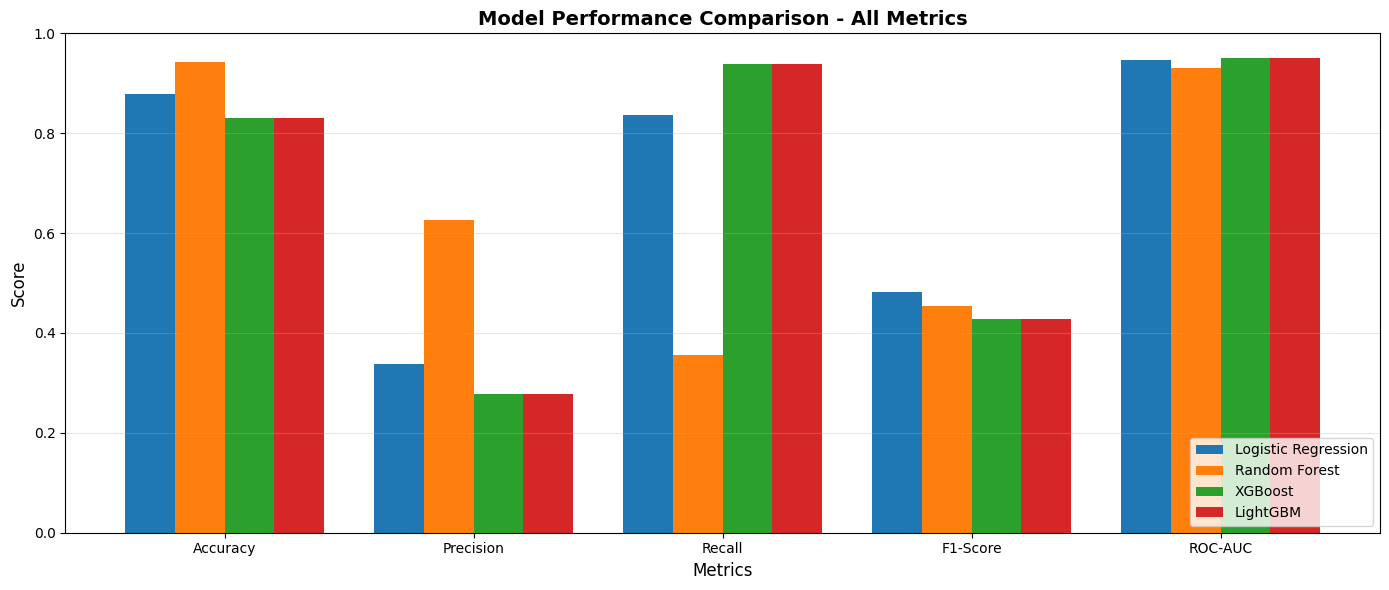

✅ Model comparison chart displayed!


In [231]:
# Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(14, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

for i, model_name in enumerate(results_df['Model']):
    values = results_df.iloc[i][metrics].values
    ax.bar(x + i * width, values, width, label=model_name)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("✅ Model comparison chart displayed!")

### Visualization 2: Feature Importance (Best Model)

Identify the most influential features for predictions.

📊 Feature Importance for: XGBoost


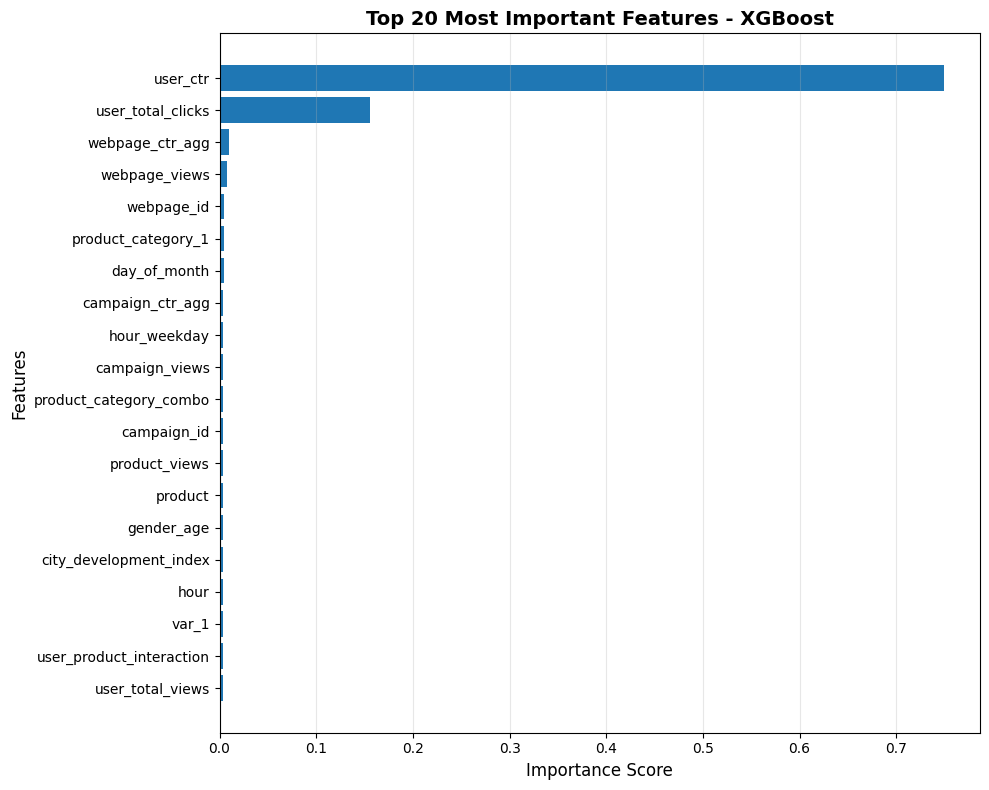


✅ Feature importance chart displayed!

Top 10 Most Important Features:
           Feature  Importance
          user_ctr    0.749112
 user_total_clicks    0.156015
   webpage_ctr_agg    0.009298
     webpage_views    0.007598
        webpage_id    0.004573
product_category_1    0.004533
      day_of_month    0.004494
  campaign_ctr_agg    0.004057
      hour_weekday    0.003515
    campaign_views    0.003404


In [232]:
# Get best model by ROC-AUC
best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_model = models[best_model_name]

print(f"📊 Feature Importance for: {best_model_name}")

# Get feature importance (tree-based models only)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # Plot top 20 features
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title(f'Top 20 Most Important Features - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Feature importance chart displayed!")
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))
else:
    print(f"\n⚠️ {best_model_name} doesn't provide feature importance scores.")

### Visualization 3: Confusion Matrix

Understand the types of errors the model makes.

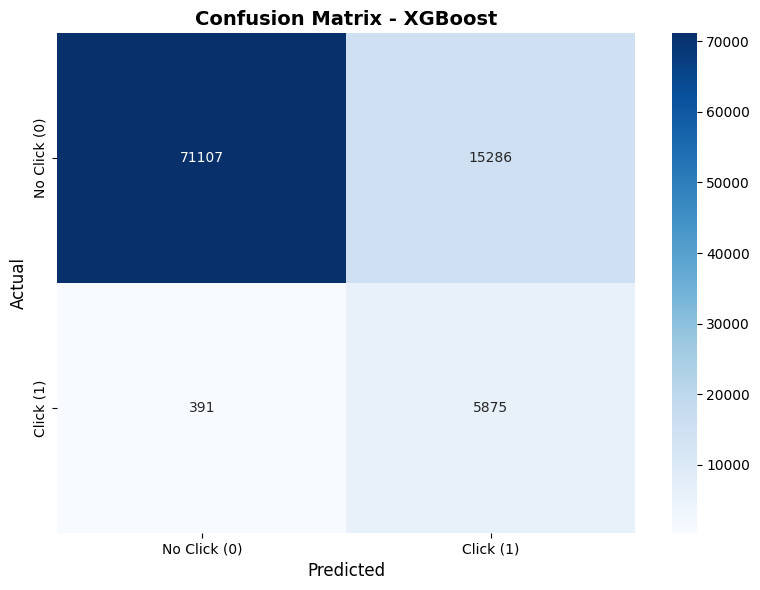


✅ Confusion Matrix for XGBoost

Breakdown:
  True Negatives (TN):  71,107 - Correctly predicted No Click
  False Positives (FP): 15,286 - Incorrectly predicted Click
  False Negatives (FN): 391 - Incorrectly predicted No Click
  True Positives (TP):  5,875 - Correctly predicted Click

💡 Business Interpretation:
  • False Positives: $15,286 wasted ad impressions
  • False Negatives: $391 missed revenue opportunities


In [233]:
from sklearn.metrics import confusion_matrix

# Get predictions from best model
if best_model_name == 'Logistic Regression':
    y_pred_best = y_pred_lr
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
elif best_model_name == 'XGBoost':
    y_pred_best = y_pred_xgb
else:
    y_pred_best = y_pred_lgbm

# Calculate confusion matrix
cm = confusion_matrix(y_val, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Click (0)', 'Click (1)'],
            yticklabels=['No Click (0)', 'Click (1)'])
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅ Confusion Matrix for {best_model_name}")
print("\nBreakdown:")
print(f"  True Negatives (TN):  {cm[0, 0]:,} - Correctly predicted No Click")
print(f"  False Positives (FP): {cm[0, 1]:,} - Incorrectly predicted Click")
print(f"  False Negatives (FN): {cm[1, 0]:,} - Incorrectly predicted No Click")
print(f"  True Positives (TP):  {cm[1, 1]:,} - Correctly predicted Click")

# Business interpretation
print("\n💡 Business Interpretation:")
print(f"  • False Positives: ${cm[0, 1]:,} wasted ad impressions")
print(f"  • False Negatives: ${cm[1, 0]:,} missed revenue opportunities")

### Visualization 4: ROC Curve (Optional)

Visualize the precision-recall trade-off.

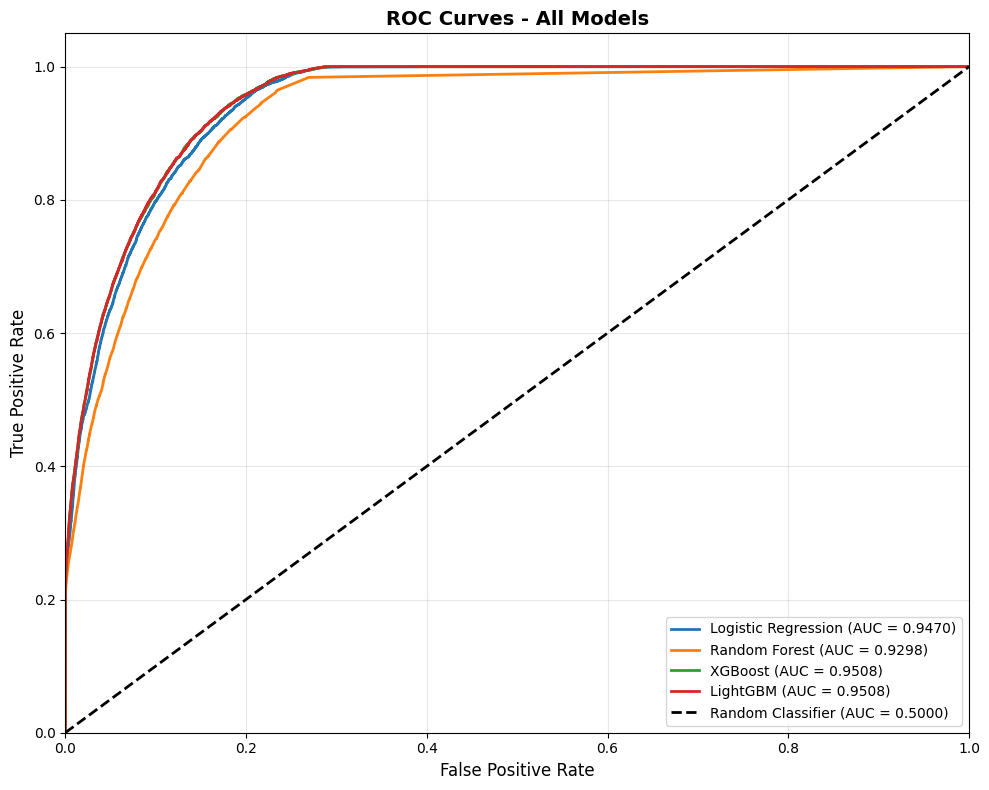

✅ ROC curves displayed for all models!

💡 Interpretation:
  • Curves closer to top-left corner = Better performance
  • Higher AUC = Better discrimination between classes
  • Diagonal line = Random guessing


In [234]:
from sklearn.metrics import roc_curve, auc

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

# Store predictions
predictions = {
    'Logistic Regression': y_pred_proba_lr,
    'Random Forest': y_pred_proba_rf,
    'XGBoost': y_pred_proba_xgb,
    'LightGBM': y_pred_proba_lgbm
}

# Plot ROC curve for each model
for model_name, y_pred_proba in predictions.items():
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ ROC curves displayed for all models!")
print("\n💡 Interpretation:")
print("  • Curves closer to top-left corner = Better performance")
print("  • Higher AUC = Better discrimination between classes")
print("  • Diagonal line = Random guessing")

## Key Insights Summary

Let's extract actionable insights from our analysis.

In [235]:
print("=" * 70)
print("KEY INSIGHTS FROM AD CLICK PREDICTION ANALYSIS")
print("=" * 70)

print("\n📊 1. BEST PERFORMING MODEL")
print("-" * 70)
best_model_idx = results_df['ROC-AUC'].idxmax()
best_model_row = results_df.iloc[best_model_idx]
print(f"  Model: {best_model_row['Model']}")
print(f"  ROC-AUC: {best_model_row['ROC-AUC']:.4f}")
print(f"  F1-Score: {best_model_row['F1-Score']:.4f}")
print(f"  Precision: {best_model_row['Precision']:.4f}")
print(f"  Recall: {best_model_row['Recall']:.4f}")
print(f"  Training Time: {best_model_row['Training Time (s)']:.2f} seconds")

if hasattr(best_model, 'feature_importances_'):
    print("\n🎯 2. TOP 5 MOST IMPORTANT FEATURES")
    print("-" * 70)
    for idx, row in feature_importance.head(5).iterrows():
        print(f"  {idx+1}. {row['Feature']:<30} (Importance: {row['Importance']:.4f})")
    
    print("\n💡 What this means:")
    top_feature = feature_importance.iloc[0]['Feature']
    if 'ctr' in top_feature.lower():
        print("  → Historical CTR metrics are the strongest predictors")
    elif 'hour' in top_feature.lower() or 'day' in top_feature.lower():
        print("  → Temporal patterns significantly influence clicks")
    elif 'user' in top_feature.lower():
        print("  → User behavior patterns are key predictors")
    elif 'product' in top_feature.lower() or 'campaign' in top_feature.lower():
        print("  → Content and campaign characteristics drive clicks")

print("\n⏰ 3. TEMPORAL PATTERNS")
print("-" * 70)
print(f"  Best performing hours: {', '.join(map(str, hourly_ctr.sort_values(ascending=False).head(3).index.tolist()))}")
print(f"  Weekend vs Weekday CTR difference: {weekdays_diff_in_per:.2%}")

print("\n🎯 4. BUSINESS RECOMMENDATIONS")
print("-" * 70)
print("  ✓ Deploy the best model for real-time ad predictions")
print("  ✓ Focus ad spend during high-CTR hours")
print("  ✓ Personalize ads based on user historical behavior")
print("  ✓ Monitor and retrain model monthly to capture trends")
print("  ✓ A/B test different ad formats in identified high-performing segments")

print("\n📈 5. MODEL PERFORMANCE ASSESSMENT")
print("-" * 70)
if best_model_row['ROC-AUC'] > 0.75:
    print("  ✅ EXCELLENT: Model shows strong discrimination ability")
elif best_model_row['ROC-AUC'] > 0.65:
    print("  ✅ GOOD: Model performs well, room for improvement")
else:
    print("  ⚠️  FAIR: Consider feature engineering or advanced techniques")

if best_model_row['F1-Score'] > 0.30:
    print("  ✅ BALANCED: Good balance between precision and recall")
else:
    print("  ⚠️  IMBALANCED: May need threshold tuning or resampling")

print("\n" + "=" * 70)
print("🎉 ANALYSIS COMPLETE!")
print("=" * 70)

KEY INSIGHTS FROM AD CLICK PREDICTION ANALYSIS

📊 1. BEST PERFORMING MODEL
----------------------------------------------------------------------
  Model: XGBoost
  ROC-AUC: 0.9508
  F1-Score: 0.4284
  Precision: 0.2776
  Recall: 0.9376
  Training Time: 5.26 seconds

🎯 2. TOP 5 MOST IMPORTANT FEATURES
----------------------------------------------------------------------
  29. user_ctr                       (Importance: 0.7491)
  28. user_total_clicks              (Importance: 0.1560)
  35. webpage_ctr_agg                (Importance: 0.0093)
  34. webpage_views                  (Importance: 0.0076)
  3. webpage_id                     (Importance: 0.0046)

💡 What this means:
  → Historical CTR metrics are the strongest predictors

⏰ 3. TEMPORAL PATTERNS
----------------------------------------------------------------------
  Best performing hours: 1, 7, 6
  Weekend vs Weekday CTR difference: 8.43%

🎯 4. BUSINESS RECOMMENDATIONS
-----------------------------------------------------------